In [1]:
# Talking about summarizing the memory. Memory can be managed two ways. 
# In-memory, External memory

## Starting with In-Memory.

In [1]:

from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages, MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, RemoveMessage
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

model = ChatGoogleGenerativeAI(model = "gemini-flash-latest", temperature = 0.7)

class State(MessagesState):
    summary: str


In [2]:

def call_model(state: State):
    """Used for model invocation on the existing message's summary, the few most recent messages, and the user input."""
    summary = state.get("messages", "")

    if summary:
        system_message = f"Summary of the conversation earlier: {summary}"
        messages = [SystemMessage(content = system_message)] + state["messages"]
    else: 
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}


In [5]:
def summarize_messages(state: State):
    """Summarizes all the stored messages if the length exceeds 6"""
    summary = state.get("summary")

    if summary:
        summary_message = f"This is the previous summary: {summary}. Take all the available messages into account and append to the previous summary creating a new one."
    else:
        summary_message = f"Please create the summary of all the messages."

    response = model.invoke(state["messages"] + [HumanMessage(content = summary_message)])

    delete_messages = [RemoveMessage(id = m.id) for m in state["messages"][: -2]]
    return {"summary" : response, "messages": delete_messages}

In [6]:
def should_summarize(state: State):
    """Return the next node to execute."""
    if len(state["messages"]) > 6:
        return "summarize_messages"
    else:
        return END

        

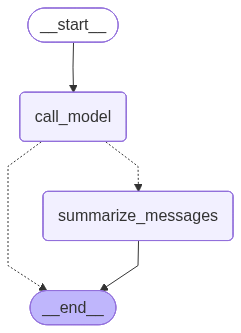

In [7]:
builder = StateGraph(State)

builder.add_node("call_model", call_model)

builder.add_node("summarize_messages", summarize_messages)

builder.add_edge(START, "call_model")
builder.add_conditional_edges(
    "call_model", 
    should_summarize,
    {
        "summarize_messages": "summarize_messages",
        END: END
    }
)
builder.add_edge("summarize_messages", END)

graph = builder.compile(checkpointer= MemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# now to make the call this Agent with memory
config = {"configurable": {"thread_id" : 1}}
input_message = HumanMessage(content = "Hi, I am Harsh")

response = graph.invoke({"messages": input_message}, config)

    

In [3]:
model.invoke(state["messages"])

NameError: name 'state' is not defined

In [7]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, I am Harsh
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Harsh! It's great to connect with you. How can I help you today?", 'extras': {'signature': 'EpgICpUIAQw51senpqmqhlDJ2Rv/E8MtyHs6Qf7VoUq0VhUjkZJ1R/Sc8tqWO/fc1CDWXUX1S+o0S65TwUTEjLl9LOeQsgHFN3TIFyEDypou2JAowUTOBU2QGtmlOcx+d5okQgV9qmIU8+fbVZA/HdYG8k4ICo/8/BZYRR9M2q6qH0sucDO2CoSSAmuQ63PLUwCxc05hvbWJk/81aLcaeD5tHbX18yLJdnLGvohPyeAPZ207V6FaCdiUcXXr/A2PpmToLjFwGis7zDvWEhSy+3wAQQtCNMaNilJ2xprbqw+N5cikBsRVlocmqtmSb0Peq68nUWKVa0U5Y2dH4yhW4j17Q3JSlahQ4M3lxx8WXLOLnq1iua9KbnVTg0mZrVeVDTZ4clF9s8Ksdg/R88cgO5XowQEIRduPuX87KrFMC7w+97C7WjWf81TR/Naw2pU1wSyrKmagq/ldkqXM7ZEz8eAmtp+ZIlEQKiuieSVH4DLLX7GTS4r2SYUmYtoZezxIEflRPUoaFdkTvAaHieodEQyQUOmSDnVVt6W3zxSaJuKwR8PQRArAAz0FbYpODqwSNLikkNgCMQij5D/PedEqEhp88dR24UCSP58IpDBYtO9m9c2JdGEAjQ4kM2N8XsWPR4r5bSnX6/4l+jZJC1VyhcJbcD2xjhqA0/Lg+vj5icSytjpYoZHCaid1AzV

In [8]:
response = graph.invoke({"messages": "What is my name"}, config)

In [9]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, I am Harsh
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hi Harsh! It's great to connect with you. How can I help you today?", 'extras': {'signature': 'EpgICpUIAQw51senpqmqhlDJ2Rv/E8MtyHs6Qf7VoUq0VhUjkZJ1R/Sc8tqWO/fc1CDWXUX1S+o0S65TwUTEjLl9LOeQsgHFN3TIFyEDypou2JAowUTOBU2QGtmlOcx+d5okQgV9qmIU8+fbVZA/HdYG8k4ICo/8/BZYRR9M2q6qH0sucDO2CoSSAmuQ63PLUwCxc05hvbWJk/81aLcaeD5tHbX18yLJdnLGvohPyeAPZ207V6FaCdiUcXXr/A2PpmToLjFwGis7zDvWEhSy+3wAQQtCNMaNilJ2xprbqw+N5cikBsRVlocmqtmSb0Peq68nUWKVa0U5Y2dH4yhW4j17Q3JSlahQ4M3lxx8WXLOLnq1iua9KbnVTg0mZrVeVDTZ4clF9s8Ksdg/R88cgO5XowQEIRduPuX87KrFMC7w+97C7WjWf81TR/Naw2pU1wSyrKmagq/ldkqXM7ZEz8eAmtp+ZIlEQKiuieSVH4DLLX7GTS4r2SYUmYtoZezxIEflRPUoaFdkTvAaHieodEQyQUOmSDnVVt6W3zxSaJuKwR8PQRArAAz0FbYpODqwSNLikkNgCMQij5D/PedEqEhp88dR24UCSP58IpDBYtO9m9c2JdGEAjQ4kM2N8XsWPR4r5bSnX6/4l+jZJC1VyhcJbcD2xjhqA0/Lg+vj5icSytjpYoZHCaid1AzV

In [14]:
response = graph.invoke({"messages": "Tell me something about Human-in-the-loop with respect to the Langchain framework."}, config)


In [15]:
for m in response['messages']:
    print(type(m))
    m.pretty_print()

<class 'langchain_core.messages.human.HumanMessage'>
================================ Human Message =================================

Tell me something about Human-in-the-loop with respect to the Langchain framework.
<class 'langchain_core.messages.ai.AIMessage'>
================================== Ai Message ==================================

[{'type': 'text', 'text': 'In the LangChain ecosystem, **Human-in-the-Loop (HITL)** has evolved from a manual workaround into a first-class, highly structured design pattern. \n\nWhile classic LangChain handles simple sequential chains, agentic workflows with loops and human intervention are built using **LangGraph**—LangChain’s specialized framework for building stateful, multi-actor applications.\n\nHere is how LangChain and LangGraph handle Human-in-the-Loop workflows, along with the core concepts and patterns they provide.\n\n---\n\n### 1. The Core Mechanism: Stateful Checkpointing\nTo pause an AI agent, wait for a human, and resume later, t

In [8]:
print(graph.get_state(config).values.get("summary").content[0].get("text"))

NameError: name 'config' is not defined

## External memory

In [ ]:
import sqlite3
# this creates an in-memory sqlite db just like the in-memory storage system we used before.
conn = sqlite3.connect(":memory:")

# this connects to a db at the given db_path in your working directory.
db_path = "db/agent_db.db"
conn = sqlite3.connect("db_path", check_same_thread= False)

In [ ]:
# to use this sqlite db created in your working directory.

from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)


sqlite_graph = builder.compile(checkpointer = memory)

In [ ]:
config = {"configurable": {"thread_id": 2}}

In [ ]:
response = sqlite_graph.invoke({"messages": "What's up? I am Harsh. Who are You?"}, config)

In [ ]:
for m in response['messages']:
    m.pretty_print()

NameError: name 'response' is not defined

In [ ]:
sqlite_graph.get_state(config).values

NameError: name 'sqlite_graph' is not defined